## Assignment-7

### Name:Vigneshwaran S
### Reg no:3122237001059

Cell Count: 1162


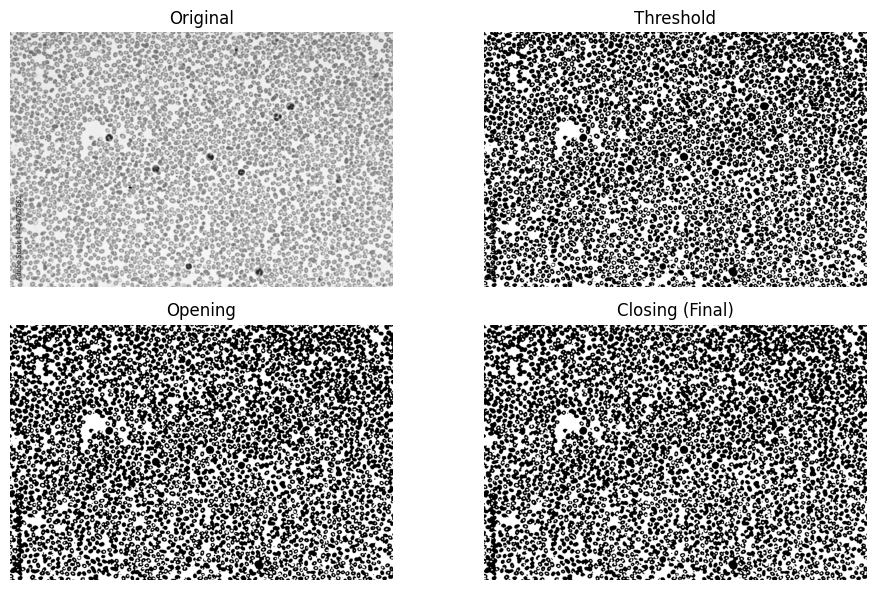

[[0 1 0]
 [1 1 1]
 [0 1 0]]


In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread("image1.jpg", 0)

# Threshold
_, thresh = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# Morphological operations
kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (3, 3))
opening = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel)
closing = cv2.morphologyEx(opening, cv2.MORPH_CLOSE, kernel)

# Count cells
num_labels, labels = cv2.connectedComponents(closing)
print("Cell Count:", num_labels - 1)

# Plot
titles = ["Original", "Threshold", "Opening", "Closing (Final)"]
images = [img, thresh, opening, closing]

plt.figure(figsize=(10, 6))
for i in range(4):
    plt.subplot(2, 2, i+1)
    plt.imshow(images[i], cmap='gray')
    plt.title(titles[i])
    plt.axis("off")
plt.tight_layout()
plt.show()

print(kernel)


Cell Count: 759


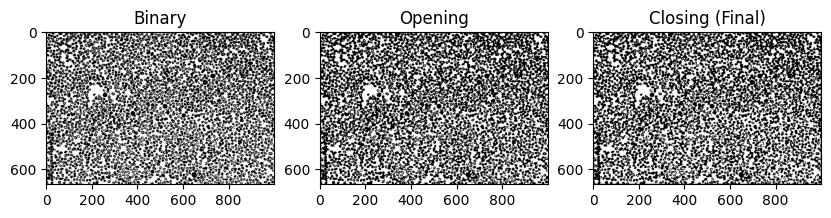

In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

def erosion(img, kernel):
    kh, kw = kernel.shape
    pad = kh // 2
    out = np.zeros_like(img)
    padded = np.pad(img, pad, mode='constant')
    for i in range(img.shape[0]):
        for j in range(img.shape[1]):
            region = padded[i:i+kh, j:j+kw]
            if np.array_equal(region & kernel, kernel):
                out[i, j] = 1
    return out

def dilation(img, kernel):
    kh, kw = kernel.shape
    pad = kh // 2
    out = np.zeros_like(img)
    padded = np.pad(img, pad, mode='constant')
    for i in range(img.shape[0]):
        for j in range(img.shape[1]):
            region = padded[i:i+kh, j:j+kw]
            if np.any(region & kernel):
                out[i, j] = 1
    return out

# Load & binarize
img = cv2.imread("image1.jpg", 0)
_, binary = cv2.threshold(img, 0, 1, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

kernel = np.ones((3,3), dtype=np.uint8)

opened = dilation(erosion(binary, kernel), kernel)
closed = erosion(dilation(opened, kernel), kernel)

num_labels, _ = cv2.connectedComponents(closed.astype(np.uint8))
print("Cell Count:", num_labels - 1)

plt.figure(figsize=(10, 6))
plt.subplot(1,3,1), plt.imshow(binary, cmap="gray"), plt.title("Binary")
plt.subplot(1,3,2), plt.imshow(opened, cmap="gray"), plt.title("Opening")
plt.subplot(1,3,3), plt.imshow(closed, cmap="gray"), plt.title("Closing (Final)")
plt.show()


In [4]:
import cv2
import numpy as np

# ---------- Dice Coefficient ----------
def dice_coefficient(img1, img2):
    # Ensure binary (0/1)
    img1 = (img1 > 0).astype(np.uint8)
    img2 = (img2 > 0).astype(np.uint8)

    intersection = np.sum(img1 * img2)
    dice = (2.0 * intersection) / (np.sum(img1) + np.sum(img2) + 1e-8)  # avoid division by zero
    return dice

# ---------- Boundary F1-score ----------
def boundary_f1_score(img1, img2, dilation_ratio=0.01):
    # Ensure binary
    img1 = (img1 > 0).astype(np.uint8)
    img2 = (img2 > 0).astype(np.uint8)

    # Extract boundaries using Canny or Morph gradient
    b1 = cv2.morphologyEx(img1, cv2.MORPH_GRADIENT, np.ones((3,3), np.uint8))
    b2 = cv2.morphologyEx(img2, cv2.MORPH_GRADIENT, np.ones((3,3), np.uint8))

    # Dilation radius for tolerance
    img_diag = np.sqrt(img1.shape[0]**2 + img1.shape[1]**2)
    dilation = max(1, int(np.round(dilation_ratio * img_diag)))

    se = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (dilation, dilation))

    # Match boundaries
    b1_dil = cv2.dilate(b1, se)
    b2_dil = cv2.dilate(b2, se)

    # Precision: fraction of predicted boundary pixels that are correct
    precision = np.sum(b1 * b2_dil) / (np.sum(b1) + 1e-8)
    # Recall: fraction of true boundary pixels that were found
    recall = np.sum(b2 * b1_dil) / (np.sum(b2) + 1e-8)

    if precision + recall == 0:
        return 0.0

    bf_score = 2 * precision * recall / (precision + recall)
    return bf_score


In [5]:
# Load your manual and built-in binary results
manual = closed
builtin = closing

# Compute metrics
dice = dice_coefficient(manual, builtin)
bf = boundary_f1_score(manual, builtin)

print(f"Dice Coefficient: {dice:.4f}")
print(f"Boundary F1-score: {bf:.4f}")


Dice Coefficient: 0.9568
Boundary F1-score: 0.9995


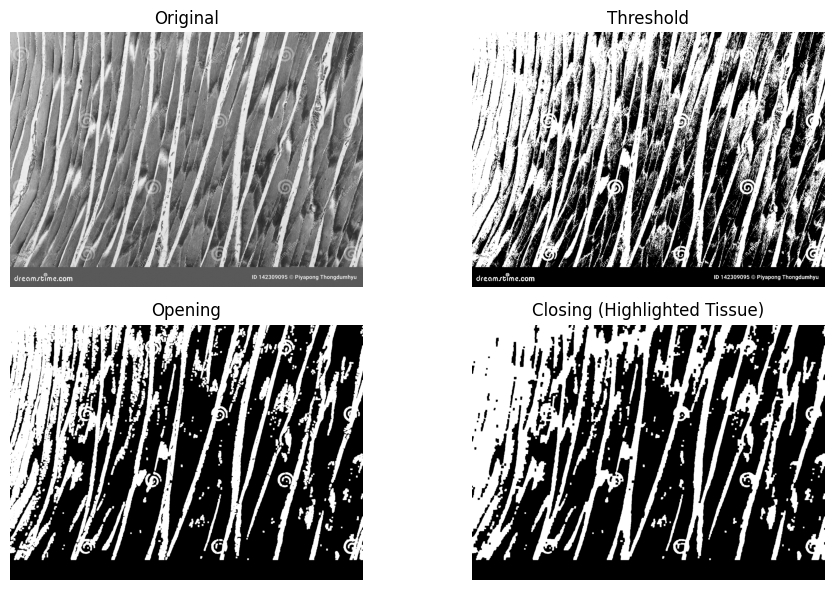

[[1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1]
 [1 1 1 1 1 1 1]]


In [6]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread("image2.webp", 0)

_, thresh = cv2.threshold(img, 127, 255, cv2.THRESH_BINARY)

kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (7,7))
opened = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel)
highlighted_b = cv2.morphologyEx(opened, cv2.MORPH_CLOSE, kernel)

titles = ["Original", "Threshold", "Opening", "Closing (Highlighted Tissue)"]
images = [img, thresh, opened, highlighted_b]

plt.figure(figsize=(10, 6))
for i in range(4):
    plt.subplot(2,2,i+1)
    plt.imshow(images[i], cmap="gray")
    plt.title(titles[i])
    plt.axis("off")
plt.tight_layout()
plt.show()
print(kernel)


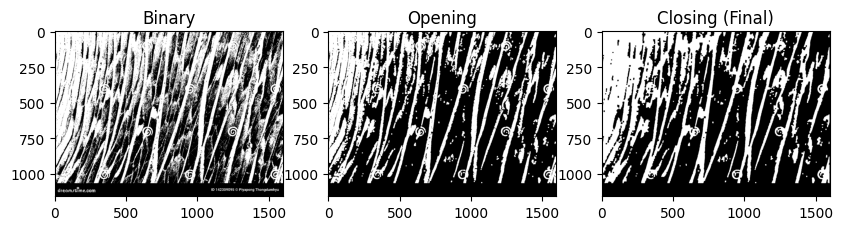

In [8]:
# reuse erosion, dilation from Task 1 manual
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread("image2.webp", 0)
_, binary = cv2.threshold(img, 127, 1, cv2.THRESH_BINARY)

kernel = np.ones((7,7), dtype=np.uint8)

opened = dilation(erosion(binary, kernel), kernel)
highlighted_m = erosion(dilation(opened, kernel), kernel)

plt.figure(figsize=(10, 5))
plt.subplot(1,3,1), plt.imshow(binary, cmap="gray"), plt.title("Binary")
plt.subplot(1,3,2), plt.imshow(opened, cmap="gray"), plt.title("Opening")
plt.subplot(1,3,3), plt.imshow(highlighted_m, cmap="gray"), plt.title("Closing (Final)")
plt.show()


In [9]:
# Load your manual and built-in binary results
manual = highlighted_m
builtin = highlighted_b

# Compute metrics
dice = dice_coefficient(manual, builtin)
bf = boundary_f1_score(manual, builtin)

print(f"Dice Coefficient: {dice:.4f}")
print(f"Boundary F1-score: {bf:.4f}")


Dice Coefficient: 0.9945
Boundary F1-score: 0.9889


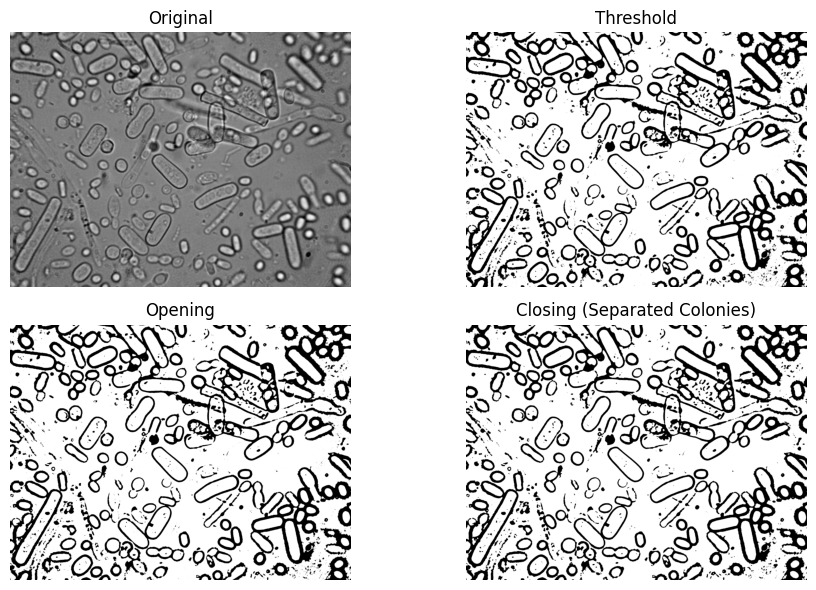

[[0 0 1 0 0]
 [0 0 1 0 0]
 [1 1 1 1 1]
 [0 0 1 0 0]
 [0 0 1 0 0]]


In [10]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread("image3.jpeg", 0)

_, thresh = cv2.threshold(img, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

kernel = cv2.getStructuringElement(cv2.MORPH_CROSS, (5,5))
opened = cv2.morphologyEx(thresh, cv2.MORPH_OPEN, kernel)
separated_b = cv2.morphologyEx(opened, cv2.MORPH_CLOSE, kernel)

titles = ["Original", "Threshold", "Opening", "Closing (Separated Colonies)"]
images = [img, thresh, opened, separated_b]

plt.figure(figsize=(10, 6))
for i in range(4):
    plt.subplot(2,2,i+1)
    plt.imshow(images[i], cmap="gray")
    plt.title(titles[i])
    plt.axis("off")
plt.tight_layout()
plt.show()

print(kernel)


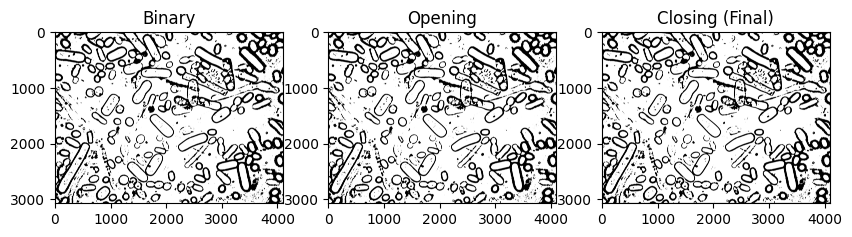

In [6]:
# reuse erosion, dilation
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread("image3.jpeg", 0)
_, binary = cv2.threshold(img, 0, 1, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

kernel = np.array([[0,1,0],
                   [1,1,1],
                   [0,1,0]], dtype=np.uint8)

opened = dilation(erosion(binary, kernel), kernel)
separated = erosion(dilation(opened, kernel), kernel)

plt.figure(figsize=(10,5))
plt.subplot(1,3,1), plt.imshow(binary, cmap="gray"), plt.title("Binary")
plt.subplot(1,3,2), plt.imshow(opened, cmap="gray"), plt.title("Opening")
plt.subplot(1,3,3), plt.imshow(separated, cmap="gray"), plt.title("Closing (Final)")
plt.show()


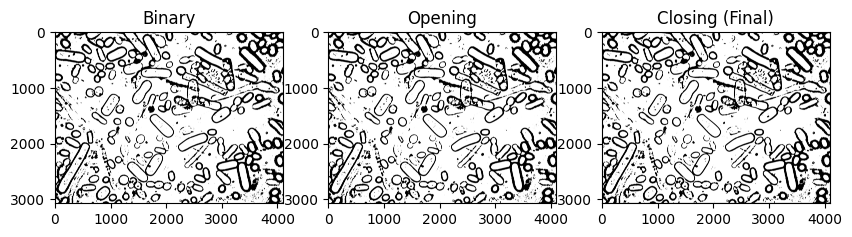

In [11]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import binary_erosion, binary_dilation

# Load grayscale image
img = cv2.imread("image3.jpeg", 0)

# Convert to binary
_, binary = cv2.threshold(img, 0, 1, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# Cross-shaped kernel
kernel = np.array([[0,1,0],
                   [1,1,1],
                   [0,1,0]], dtype=bool)

# Opening = erosion → dilation
opened = binary_dilation(binary_erosion(binary, structure=kernel), structure=kernel)

# Closing = dilation → erosion
separated_m = binary_erosion(binary_dilation(opened, structure=kernel), structure=kernel)

# Plot results
plt.figure(figsize=(10,5))
plt.subplot(1,3,1), plt.imshow(binary, cmap="gray"), plt.title("Binary")
plt.subplot(1,3,2), plt.imshow(opened, cmap="gray"), plt.title("Opening")
plt.subplot(1,3,3), plt.imshow(separated_m, cmap="gray"), plt.title("Closing (Final)")
plt.show()


In [12]:
# Load your manual and built-in binary results
manual = separated_m
builtin = separated_b

# Compute metrics
dice = dice_coefficient(manual, builtin)
bf = boundary_f1_score(manual, builtin)

print(f"Dice Coefficient: {dice:.4f}")
print(f"Boundary F1-score: {bf:.4f}")


Dice Coefficient: 0.9973
Boundary F1-score: 0.9913
